# De texto bruto a embeddings de palabras

Antes se trabajo con IMDb desde un formato pretokenizado, esta vez se partira desde el texto crudo. 

Para ello se parte del [dataset crudo de IMDb](http://mng.bz/0tIo) (hay que descomprimirlo antes de usarlo).

In [ ]:
!unzip datasets/aclImdb.zip -d datasets
!rm -rf datasets/__MACOSX

Con el conjunto de datos en el sistema de archivos local recolectar todas las entradas textuales y la etiqueta (positiva:1 o negativa:0) que le corresponde a cada una.

In [1]:
import os

imdb_dir = os.path.expanduser('~/libros/dlwp/datasets/aclImdb')
train_dir = os.path.join(imdb_dir, 'train')

labels = []
texts = []

for label_type in ['neg', 'pos']:
    dir_name = os.path.join(train_dir, label_type)
    for fname in os.listdir(dir_name):
        if(fname[-4:] =='.txt'):
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
            if(label_type=='neg'):
                labels.append(0)
            else:
                labels.append(1)

print(len(texts),len(labels))

25000 25000


Ahora se realiza el Tokenizado. 

Para ejemplificar bien en que casos es de utilidad el uso de embeddings de palabras preentrenados solo se usaran 200 muestras para el conjunto de entrenamiento.

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

maxlen = 100    # Solo usar las 1ras 100 palabras de una reseña
training_samples = 200
validation_samples = 10000
max_words = 10000    # Considerar solo el top 10.000 palabras 

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)    # Arma el vocabulario con todo el dataset
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.'% len(word_index))

data = pad_sequences(sequences, maxlen) # Trunca/rellena las palabras por reseña

labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of labels tensor:', labels.shape)

indices = np.arange(data.shape[0]) # Mezclar los datos
np.random.shuffle(indices)
data = data[indices]
labels = labels[indices]

x_train = data[:training_samples]
y_train = labels[:training_samples]
x_val = data[training_samples:training_samples+validation_samples]
y_val = labels[training_samples:training_samples+validation_samples]

2025-08-31 15:15:01.110535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756664101.128413  148439 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756664101.133814  148439 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1756664101.147885  148439 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756664101.147908  148439 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1756664101.147910  148439 computation_placer.cc:177] computation placer alr

Found 88582 unique tokens.
Shape of data tensor: (25000, 100)
Shape of labels tensor: (25000,)


Es normal que se muestren 88582 tokens unicos ya que `word_index` arma el vocabulario en base a TODO el texto, el toquenizado de sequence aun se arma solo con las 10000 palabras mas frecuentes.

# Descargando embeddings de palabras preentrenados de GloVe

Descargar el grupo de embeddings de palabras preentrenado *glove.6B* desde la [página de GloVe](https://nlp.stanford.edu/projects/glove) luego descomprimirlos.

Se trata de un archivo de embeddings construidos con la Wikipedia en Ingles de 2014, con embeddings de palabras 100 dimensionales para 400.000 palabras.

In [36]:
!mkdir embeddings/glove.6B
!unzip embeddings/glove.6B.zip -d embeddings/glove.6B

Archive:  embeddings/glove.6B.zip
  inflating: embeddings/glove.6B/glove.6B.50d.txt  
  inflating: embeddings/glove.6B/glove.6B.100d.txt  
  inflating: embeddings/glove.6B/glove.6B.200d.txt  
  inflating: embeddings/glove.6B/glove.6B.300d.txt  


In [3]:
import os

glove_dir = os.path.expanduser('~/libros/dlwp/embeddings/glove.6B')

embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.100d.txt'))
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print(values)
print('Found %s word vectors.' % len(embeddings_index)) 

['sandberger', '0.28365', '-0.6263', '-0.44351', '0.2177', '-0.087421', '-0.17062', '0.29266', '-0.024899', '0.26414', '-0.17023', '0.25817', '0.097484', '-0.33103', '-0.43859', '0.0095799', '0.095624', '-0.17777', '0.38886', '0.27151', '0.14742', '-0.43973', '-0.26588', '-0.024271', '0.27186', '-0.36761', '-0.24827', '-0.20815', '0.22128', '-0.044409', '0.021373', '0.24594', '0.26143', '0.29303', '0.13281', '0.082232', '-0.12869', '0.1622', '-0.22567', '-0.060348', '0.28703', '0.11381', '0.34839', '0.3419', '0.36996', '-0.13592', '0.0062694', '0.080317', '0.0036251', '0.43093', '0.01882', '0.31008', '0.16722', '0.074112', '-0.37745', '0.47363', '0.41284', '0.24471', '0.075965', '-0.51725', '-0.49481', '0.526', '-0.074645', '0.41434', '-0.1956', '-0.16544', '-0.045649', '-0.40153', '-0.13136', '-0.4672', '0.18825', '0.2612', '0.16854', '0.22615', '0.62992', '-0.1288', '0.055841', '0.01928', '0.024572', '0.46875', '0.2582', '-0.31672', '0.048591', '0.3277', '-0.50141', '0.30855', '0.119

Ahora construir una matriz de embeddings que se pueda cargar en una capa `Embedding`. 

En escencia se esta insertando un diccionario *indice de palabra -> embedding* dentro del modelo para cada palabra del vocabulario. La *key* del diccionario viene dada por la posicion del embedding en la matriz.

In [4]:
embedding_dim = 100

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    # Dentro de word_index las palabras de texts estan ordenadas por frecuencia
    # controlar que el indice sea menor que la cantidad de palabras del 
    # vocabulario asegura que no se consideren las palabras menonos frecuentes
    if i < max_words:   
        embedding_vector = embeddings_index.get(word)
        # Puede que el conjunto de embeddings preentrenados desconosca palabras
        # que si estan en texts
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

Notar que si una palabra no es encontrada en el `embeddings_index` simplemente se le deja un embedding de todo ceros.

# Definir el modelo

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_shape=(maxlen,)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,065 (5.04 MB)

 Trainable params: 1,320,065 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

# Incorporar GloVe embeddings en el modelo

Cargar los embeddings preentrenados en el modelo.

Congelar los pesos de los embeddings para evitar que las iteraciones de descenso gradiente iniciales destrocen la estructura de estos. Similar a lo visto con *Convnets*.

In [34]:
model.layers[0].set_weights([embedding_matrix])
model.layers[0].trainable = False

# Entrenar el modelo

In [35]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val,y_val))
model.save('./models/pre_trained_glove_model.h5')

Epoch 1/10


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - acc: 0.4916 - loss: 1.8066 - val_acc: 0.5007 - val_loss: 0.6931
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 0.6148 - loss: 0.6752 - val_acc: 0.5075 - val_loss: 0.7290
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 0.6621 - loss: 0.5654 - val_acc: 0.5059 - val_loss: 0.7736
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 0.8477 - loss: 0.4076 - val_acc: 0.5214 - val_loss: 0.7678
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - acc: 0.8239 - loss: 0.3960 - val_acc: 0.5086 - val_loss: 0.8577
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 0.7600 - loss: 0.3872 - val_acc: 0.5612 - val_loss: 0.7100
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - acc: 0.9981 - loss: 0.1174 - val_acc: 0.5091 - val_loss: 1.0178
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - acc: 1.0000 - loss: 0.1134 - val_acc: 0.5280 - val_loss: 0.8948
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - acc: 0.9927 - loss: 0.1002 - val_acc: 0

El rendimiento en train es casi perfecto en las ultimas epocas, pero en validacion se mantiene estable funcionando apenas mejor que tierar una moneda (>50% de *acc*). 

Es un comportamiento esperable ya que se esta trabajando con apenas 200 muestras en train las cuales dificilemnte pueden entrenar las demas capas no congeladas del modelo.

El comportamiento es mas evidente en forma de curva.

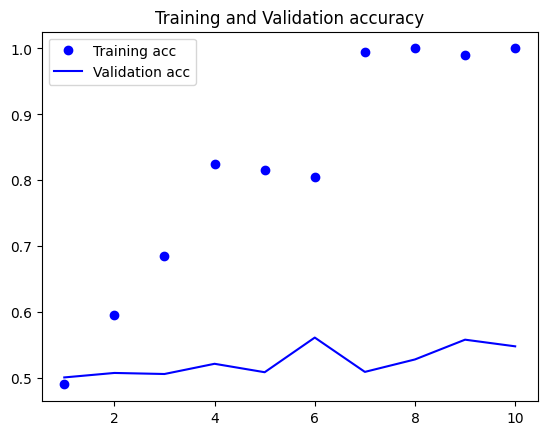

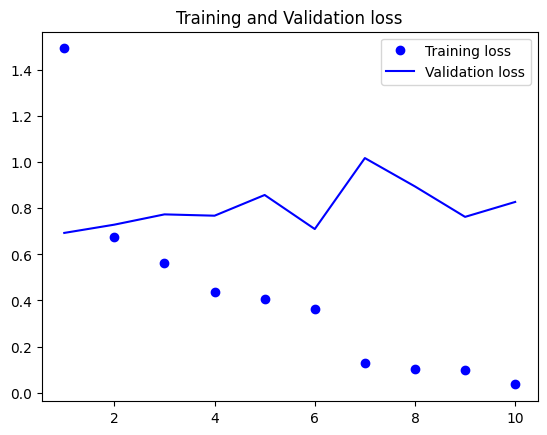

In [36]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

Otra opcion es declarar la capa de embeddings sin realizar ninguna carga de embeddings preentrenados, esto permite que se entrenen embeddins propios del problema. Suele ser mas beneficioso ya que se capturan patrones mas personalizados. No obstante, es un problema si se tienen muy pocos datos de entrenamiento (como en este caso). 

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_shape=(maxlen,)))
model.add(Flatten())
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(x_val,y_val))
model.save('./models/pre_trained_glove_model.h5')

/home/sponte/libros/dlwp/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 10000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │       320,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,065 (5.04 MB)

 Trainable params: 1,320,065 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 638ms/step - acc: 0.5423 - loss: 0.6941 - val_acc: 0.5251 - val_loss: 0.6913
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - acc: 0.9552 - loss: 0.5557 - val_acc: 0.5198 - val_loss: 0.6931
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 0.9687 - loss: 0.4006 - val_acc: 0.5321 - val_loss: 0.6972
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - acc: 0.9810 - loss: 0.2291 - val_acc: 0.5266 - val_loss: 0.7013
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - acc: 1.0000 - loss: 0.1219 - val_acc: 0.5286 - val_loss: 0.7044
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - acc: 1.0000 - loss: 0.0678 - val_acc: 0.5309 - val_loss: 0.7097
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 1.0000 - loss: 0.0404 - val_acc: 0.5322 - val_loss: 0.7202
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - acc: 1.0000 - loss: 0.0255 - val_acc: 0.5309 - val_loss: 0.7294
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - acc: 1.0000 - loss: 0.0173 

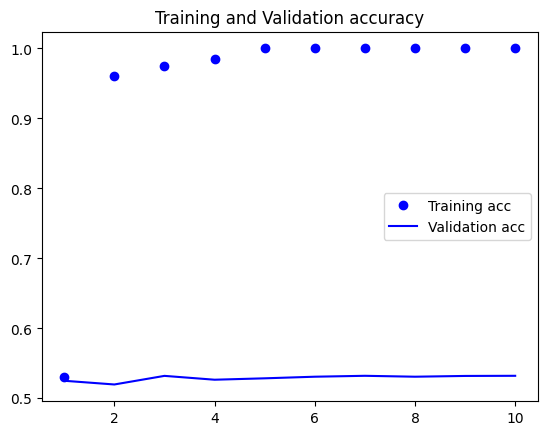

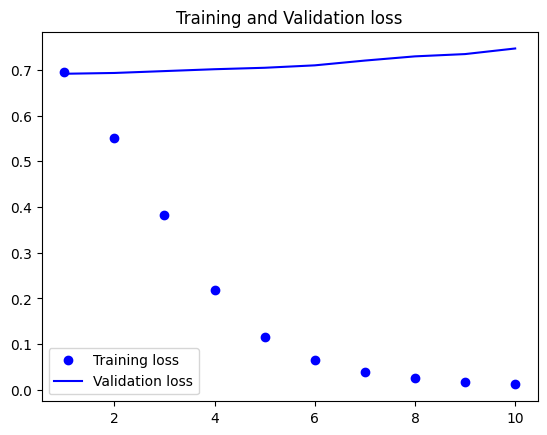

In [38]:
import matplotlib.pyplot as plt

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and Validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

Se aprecia que que los valores de acc son un poco peores, antes sobre 54%-55%, ahora sobre 52%-53%. En este caso (con pocos datos de train) es preferible usar embeddings preentrenados a entrenarlos. 

Hay menos ruido en *validation* que en el caso anterior. El modelo predice train con muy alto accuracy desde una epocas tempranas. Entonces, fallos hallados en train cada vez menos significativos. Entonces, cada vez menos modificaciones por desenso gradiente cada vez son menores. Entonces, el modelo cambia menos. Entonces, si los mismos datos de validacion son evaluados con el mismo modelo los resultados seran los mismos. Entonces, habra menos ruido en *validation*.

A continuacion se evalua el rendimiento del primer modelo (embeddings preentrenados) en los datos de test.

In [40]:
test_dir = os.path.join(imdb_dir, 'test')

labels = []
texts = []

for label_type in ['neg', 'pos']:
    dir_name = os.path.join(test_dir, label_type)
    for fname in sorted(os.listdir(dir_name)):
        if fname[-4:] == '.txt':
            f = open(os.path.join(dir_name, fname))
            texts.append(f.read())
            f.close()
        if label_type == 'neg':
            labels.append(0)
        else:
            labels.append(1)

# Es el mismo tokenazes que se uso antes por lo que las palabras que considera son las mismas
sequences = tokenizer.texts_to_sequences(texts)
x_test = pad_sequences(sequences, maxlen=maxlen) 
y_test = np.asarray(labels)

In [41]:
model.load_weights('models/pre_trained_glove_model.h5')
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.5597 - loss: 0.7226


[0.7533166408538818, 0.5281199812889099]

Similar al rendimiento del conjunto de validacion del mismo modelo.